In [1]:
# Standard library imports
import json
import os
from datetime import datetime

# Third-party imports
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
import math

# ---------------------------------
# Config
# ---------------------------------
DATA_XLSX = '../data/multi_site_data.xlsx'
RAW_SHEET = 'RawData'
DAILY_SUMMS_SHEET = 'DailySummaries'
BIRDCAST_PARQUET = '../../birdcast-data-grabber/data/birdcast_data.parquet'
load_dotenv()

# Create dashboard output directory
DASHBOARD_DIR = '../docs/dashboard_plots'
os.makedirs(DASHBOARD_DIR, exist_ok=True)
os.makedirs(f'{DASHBOARD_DIR}/images', exist_ok=True)
os.makedirs(f'{DASHBOARD_DIR}/interactive', exist_ok=True)

# Time-binning config
TIME_BIN_START_HOUR = 0     # 6 AM
TIME_BIN_END_HOUR = 23      # 8 PM (20 in 24h)
TIME_BIN_MINUTES = 30       # 30-minute bins

# Function to save matplotlib plots
def save_plot_for_dashboard(fig, filename, title, description=""):
    """Save matplotlib figure for dashboard with metadata."""
    # Save as high-res PNG
    png_path = f'{DASHBOARD_DIR}/images/{filename}.png'
    fig.savefig(png_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    # Create metadata file
    metadata = {
        'title': title,
        'description': description,
        'filename': filename,
        'type': 'matplotlib',
        'created': datetime.now().isoformat(),
        'image_path': f'images/{filename}.png'
    }
    
    with open(f'{DASHBOARD_DIR}/{filename}.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"Saved: {title} -> {filename}")
    return filename

In [2]:
# Load data from Excel
raw_data = pd.read_excel(DATA_XLSX, sheet_name=RAW_SHEET)
raw_data = raw_data.dropna(subset=['RightPecks'])
raw_data['Date'] = pd.to_datetime(raw_data['Date'])

daily_summs = pd.read_excel(DATA_XLSX, sheet_name=DAILY_SUMMS_SHEET)
daily_summs['Date'] = pd.to_datetime(daily_summs['Date'])

In [3]:
peck_data = raw_data[['Date', 'Bird', 'RightPecks', 'LeftPecks', 'RightSeed', 'LeftSeed']]
peck_data = peck_data.groupby(['Date', 'Bird']).agg(
    right_pecks = ('RightPecks', 'sum'),
    left_pecks = ('LeftPecks', 'sum'),
    right_seeds = ('RightSeed', 'first'),
    left_seeds = ('LeftSeed', 'first')
).reset_index()
peck_data[['right_pecks', 'left_pecks']] = peck_data[['right_pecks', 'left_pecks']]+1
peck_data['log_ratio_left_right'] = np.log(peck_data['left_pecks'] / peck_data['right_pecks'])

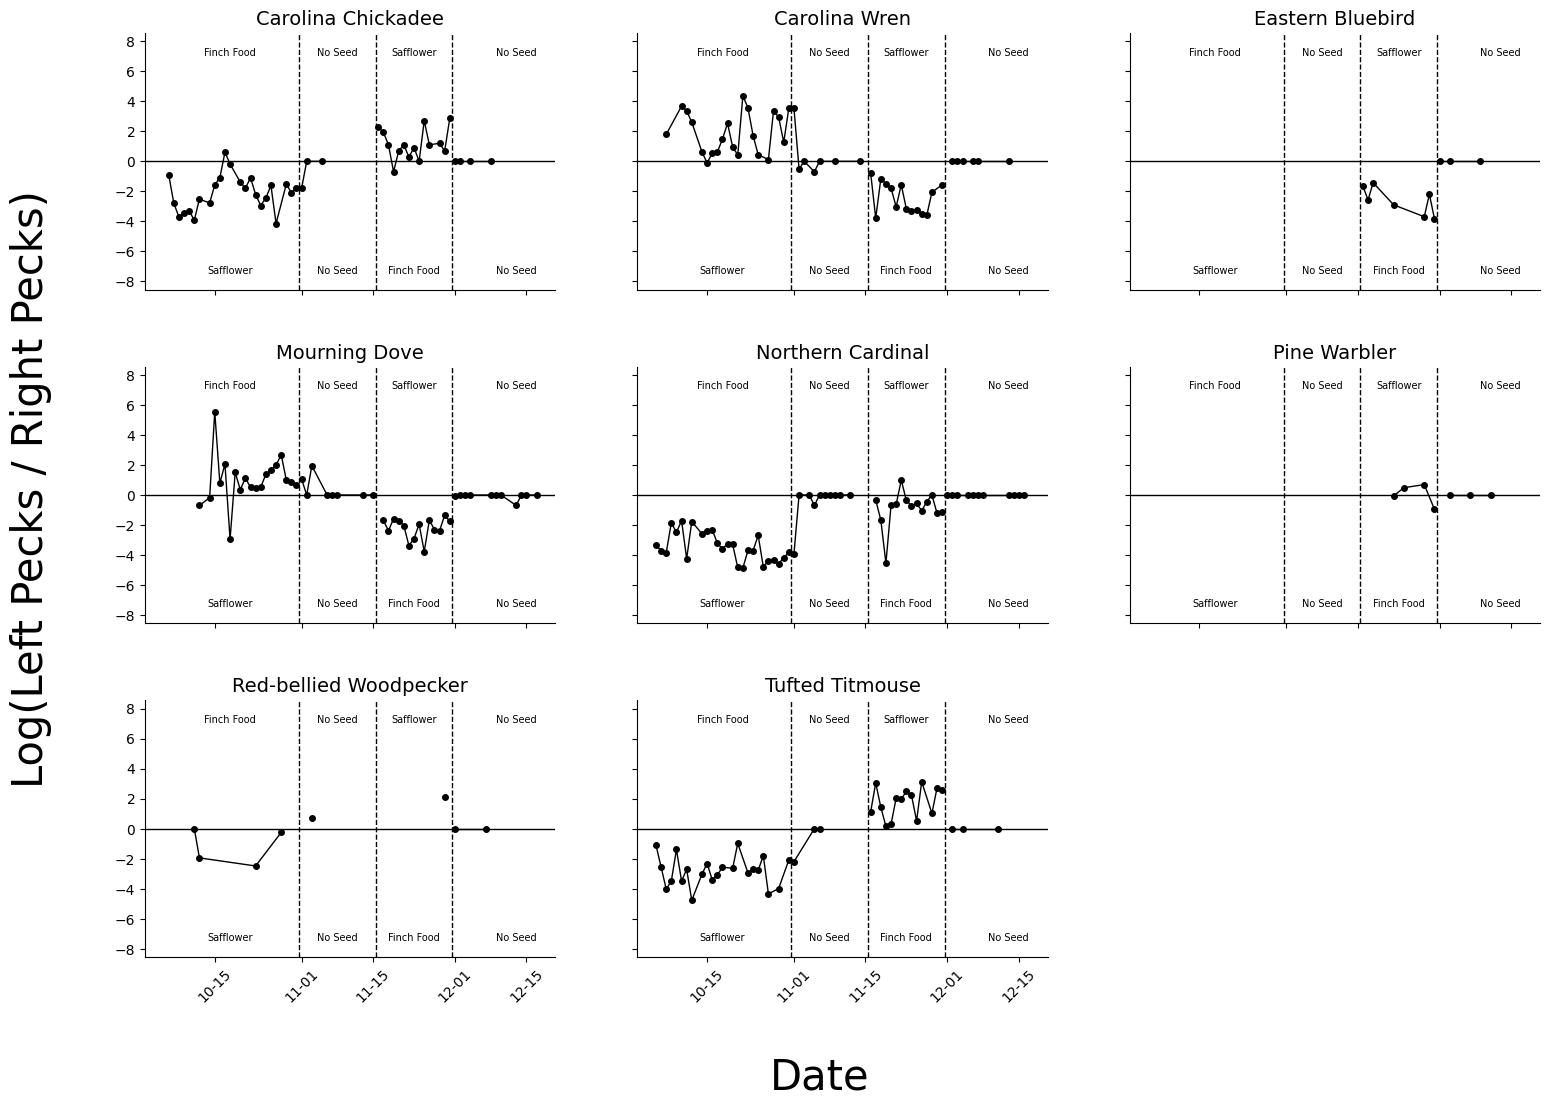

Saved: Seed Preference by Bird and Feeder Side
(Right Side More Open) -> seed_preference_by_bird


'seed_preference_by_bird'

In [4]:
# --- Prep data ---
peck_data['Date'] = pd.to_datetime(peck_data['Date'])

boundary1 = pd.to_datetime('2025-11-01')
boundary2 = pd.to_datetime('2025-11-16')
boundary3 = pd.to_datetime('2025-12-01')

# Global midpoints for phase-change lines (using all data)
prev1 = peck_data.loc[peck_data['Date'] < boundary1, 'Date'].max()
next1 = peck_data.loc[peck_data['Date'] >= boundary1, 'Date'].min()
mid1  = prev1 + (next1 - prev1) / 2

prev2 = peck_data.loc[peck_data['Date'] < boundary2, 'Date'].max()
next2 = peck_data.loc[peck_data['Date'] >= boundary2, 'Date'].min()
mid2  = prev2 + (next2 - prev2) / 2

prev3 = peck_data.loc[peck_data['Date'] < boundary3, 'Date'].max()
next3 = peck_data.loc[peck_data['Date'] >= boundary3, 'Date'].min()
mid3  = prev3 + (next3 - prev3) / 2

# Phase label midpoints
phase_a_start = peck_data['Date'].min()
phase_a_end   = prev1
mid_a = phase_a_start + (phase_a_end - phase_a_start) / 2

phase_b_start = next1
phase_b_end   = prev2
mid_b = phase_b_start + (phase_b_end - phase_b_start) / 2

phase_c_start = next2
phase_c_end   = prev3
mid_c = phase_c_start + (phase_c_end - phase_c_start) / 2

phase_d_start = next3
phase_d_end   = peck_data['Date'].max()
mid_d = phase_d_start + (phase_d_end - phase_d_start) / 2

# --- NEW: filter birds with at least 8 days of data ---
days_per_bird = peck_data.groupby('Bird')['Date'].nunique()
birds = sorted(days_per_bird[days_per_bird >= 5].index)

n_birds = len(birds)
n_cols = 3
n_rows = math.ceil(n_birds / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 4 * n_rows),
    sharex=True, 
    sharey=True
)
axes = axes.flatten()

# Global y-limits
max_y = max(
    np.abs(peck_data['log_ratio_left_right'].min()),
    peck_data['log_ratio_left_right'].max()
) + 3

for i, (ax, bird) in enumerate(zip(axes, birds)):
    df = peck_data[peck_data['Bird'] == bird].sort_values('Date')

    # Split by phase
    data_phase_a = df[df['Date'] < boundary1]
    data_phase_b = df[(df['Date'] >= boundary1) & (df['Date'] < boundary2)]
    data_phase_c = df[(df['Date'] >= boundary2) & (df['Date'] < boundary3)]
    data_phase_d = df[df['Date'] >= boundary3]

    ax.plot(data_phase_a['Date'], data_phase_a['log_ratio_left_right'],
            marker='o', markersize=4, markerfacecolor='black',
            markeredgecolor='black', markeredgewidth=1,
            linewidth=1, color='black')

    ax.plot(data_phase_b['Date'], data_phase_b['log_ratio_left_right'],
            marker='o', markersize=4, markerfacecolor='black',
            markeredgecolor='black', markeredgewidth=1,
            linewidth=1, color='black')

    ax.plot(data_phase_c['Date'], data_phase_c['log_ratio_left_right'],
            marker='o', markersize=4, markerfacecolor='black',
            markeredgecolor='black', markeredgewidth=1,
            linewidth=1, color='black')

    ax.plot(data_phase_d['Date'], data_phase_d['log_ratio_left_right'],
            marker='o', markersize=4, markerfacecolor='black',
            markeredgecolor='black', markeredgewidth=1,
            linewidth=1, color='black')

    # Phase-change lines (same positions for all birds)
    ax.axvline(x=mid1, color='black', linestyle='--', linewidth=1)
    ax.axvline(x=mid2, color='black', linestyle='--', linewidth=1)
    ax.axvline(x=mid3, color='black', linestyle='--', linewidth=1)
    ax.axhline(y=0, color='black', linewidth=1)

    sns.despine(ax=ax, top=True, right=True)
    ax.set_ylim(-max_y, max_y)

    ax.set_title(bird, fontsize=14)

# Turn off any unused axes
for j in range(len(birds), len(axes)):
    axes[j].axis('off')

# Phase labels in the first row
y_label_top = max_y * 0.85
y_label_bottom = -y_label_top
for ax in axes[:-1]:
    ax.text(mid_a, y_label_top, 'Finch Food', ha='center', va='center', fontsize=7)
    ax.text(mid_a, y_label_bottom, 'Safflower', ha='center', va='center', fontsize=7)
    ax.text(mid_b, y_label_top, 'No Seed', ha='center', va='center', fontsize=7)
    ax.text(mid_b, y_label_bottom, 'No Seed', ha='center', va='center', fontsize=7)
    ax.text(mid_c, y_label_top, 'Safflower', ha='center', va='center', fontsize=7)
    ax.text(mid_c, y_label_bottom, 'Finch Food', ha='center', va='center', fontsize=7)
    ax.text(mid_d, y_label_top, 'No Seed', ha='left', va='center', fontsize=7)
    ax.text(mid_d, y_label_bottom, 'No Seed', ha='left', va='center', fontsize=7)

# Format x-ticks as MM-DD and rotate 45°
date_fmt = mdates.DateFormatter('%m-%d')
for ax in axes:
    ax.xaxis.set_major_formatter(date_fmt)
    ax.tick_params(axis='x', labelrotation=45)

fig.text(0.5, 0.0, 'Date', ha='center', fontsize=30)
fig.text(0.05, 0.5, 'Log(Left Pecks / Right Pecks)', va='center',
         rotation='vertical', fontsize=30)

# plt.tight_layout(rect=[0.05, 0.06, 1, 0.93])
plt.subplots_adjust(hspace=0.3)
plt.show()

# Save diversity metrics plot for dashboard
save_plot_for_dashboard(
    fig, 
    'seed_preference_by_bird', 
    'Seed Preference by Bird and Feeder Side\n(Right Side More Open)',
    'Seed preference by bird'
)

/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_9392/1121007719.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bird_data['TotalPecks'] = bird_data['RightPecks'] + bird_data['LeftPecks']
/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_9392/1121007719.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bird_data['TotalPecks'] = bird_data['RightPecks'] + bird_data['LeftPecks']
/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_9392/1121007719.py:21: SettingWithCopyWarning: 

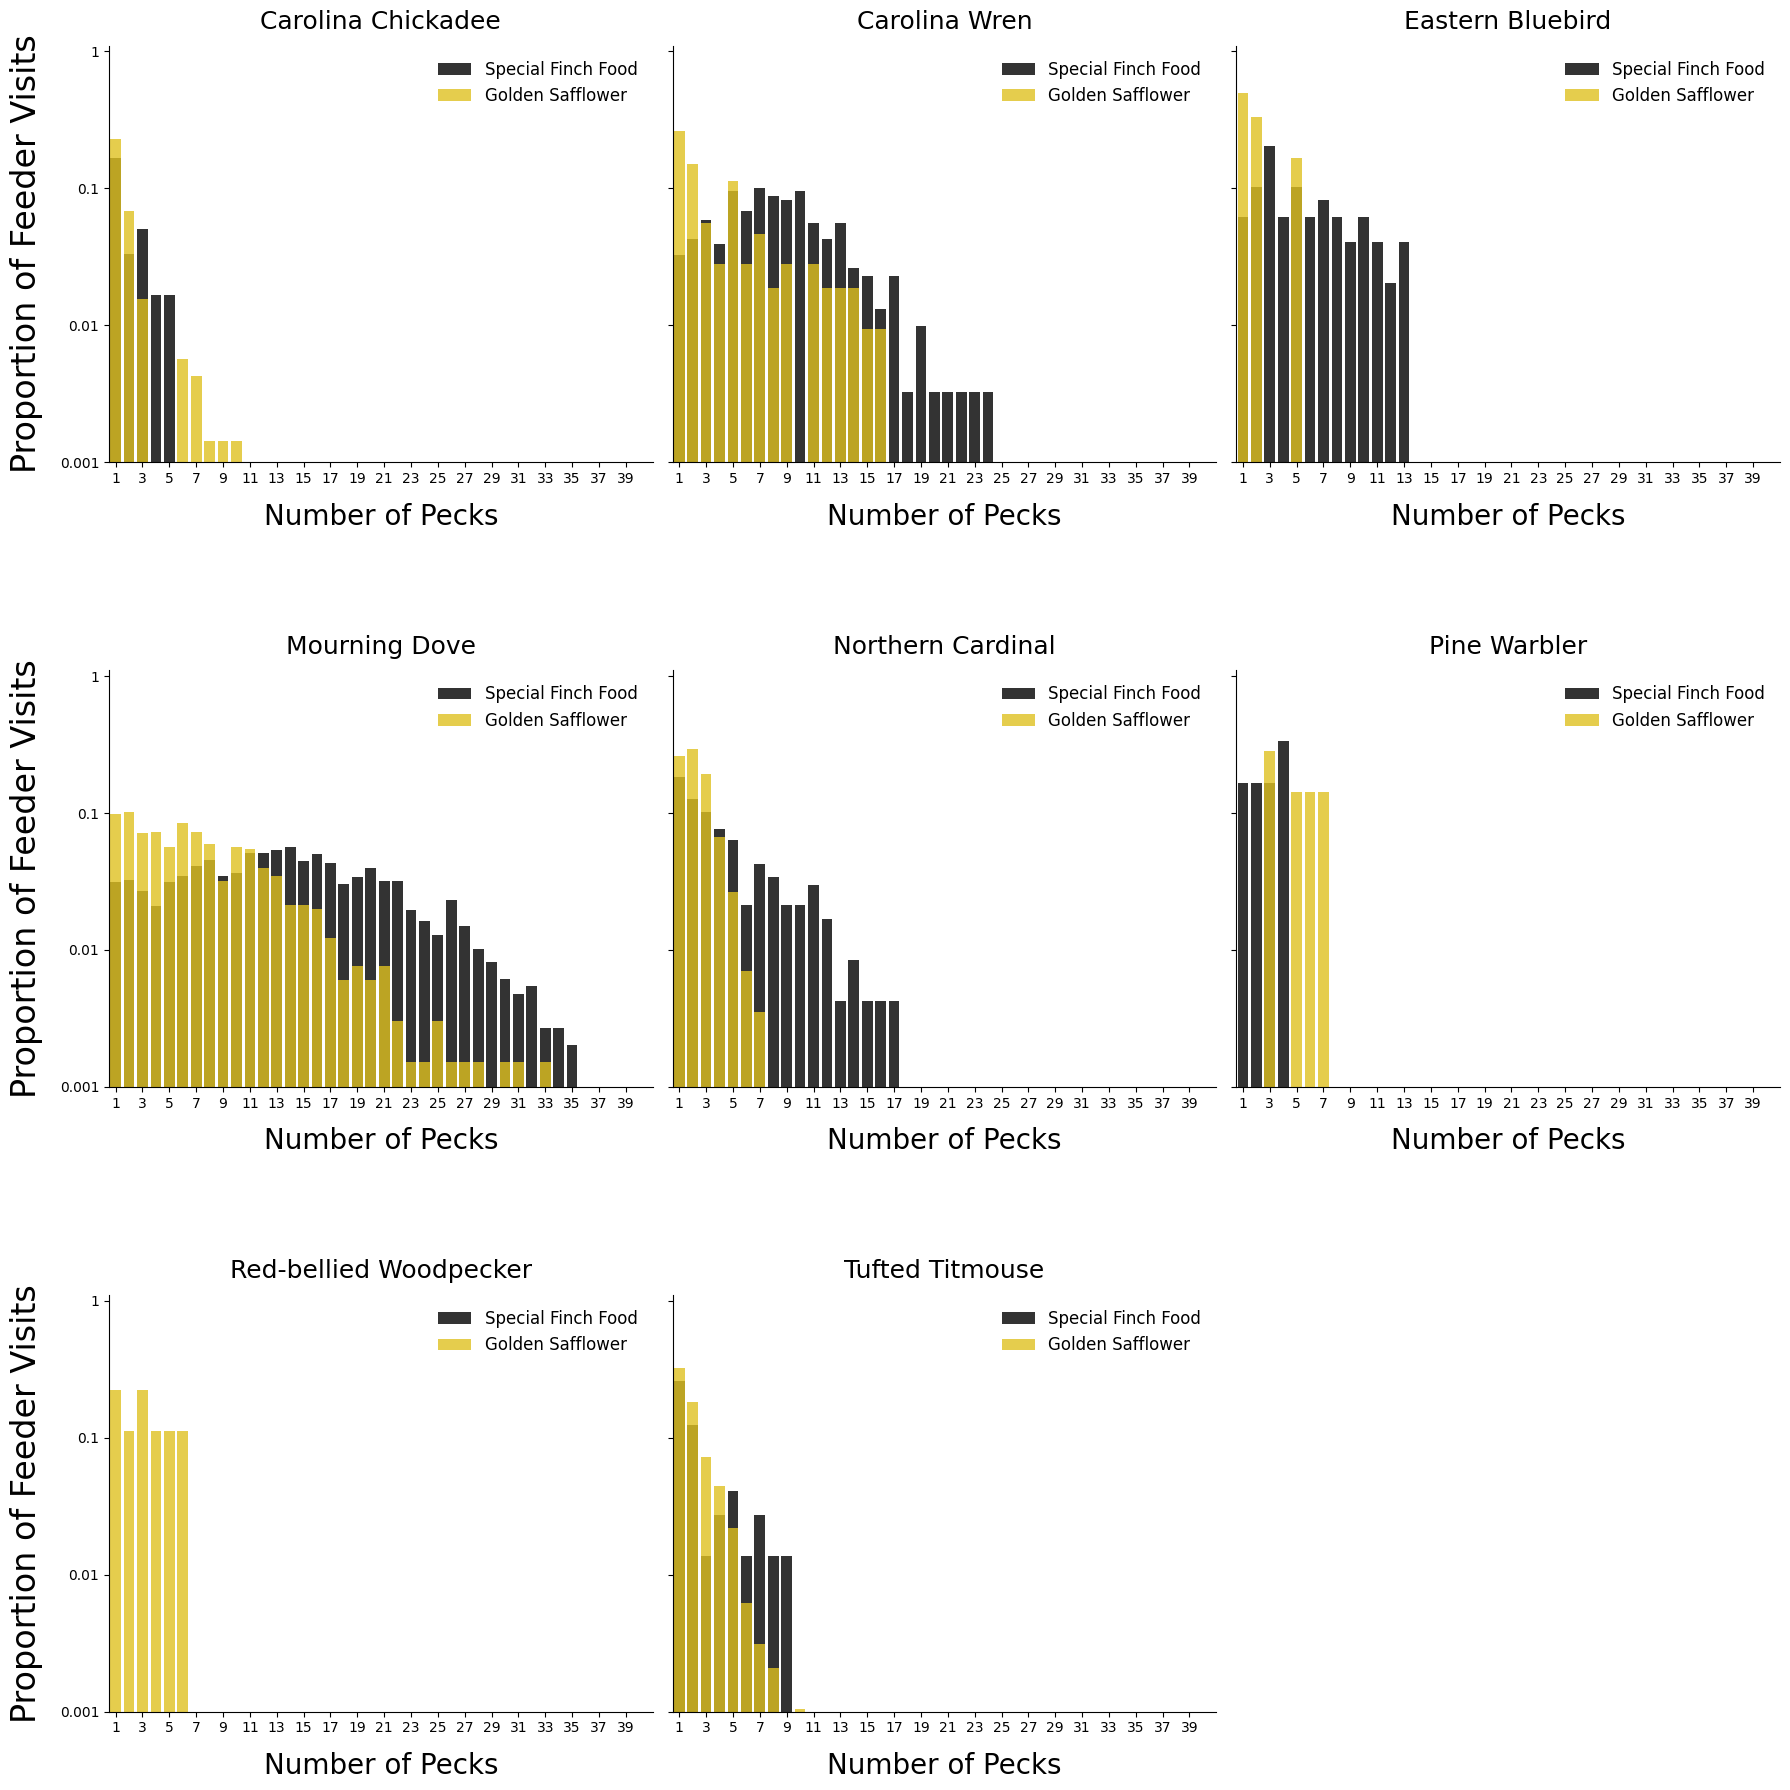

Saved: Number of Pecks per Visit by Seed Type -> peck_distribution_by_bird


'peck_distribution_by_bird'

In [5]:
# Get all unique birds
bird_counts = raw_data['Bird'].value_counts().reset_index()
bird_counts = bird_counts[bird_counts['count'] >= 10]
unique_birds = sorted(bird_counts['Bird'].unique())
n_birds = len(unique_birds)

# Calculate grid dimensions (aim for roughly square layout)
n_cols = int(3)
n_rows = int(np.ceil(n_birds / n_cols))

# Create subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows), sharey=True)
axes = axes.flatten() if n_birds > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes.flatten()

# Process and plot each bird
for idx, bird in enumerate(unique_birds):
    ax = axes[idx]
    
    # Filter data for this bird
    bird_data = raw_data[(raw_data['Bird'] == bird)]
    bird_data['TotalPecks'] = bird_data['RightPecks'] + bird_data['LeftPecks']
    
    # Process Golden Safflower pecks
    saff_pecks_a = bird_data[bird_data['RightSeed'] == 'Golden Safflower']['RightPecks'].value_counts()   
    saff_pecks_b = bird_data[bird_data['LeftSeed'] == 'Golden Safflower']['LeftPecks'].value_counts()
    plot_saff_a = saff_pecks_a.reset_index()
    plot_saff_b = saff_pecks_b.reset_index()
    plot_saff_a.columns = ['Pecks', 'Count']
    plot_saff_b.columns = ['Pecks', 'Count']
    saff_df = pd.merge(plot_saff_a, plot_saff_b, on='Pecks', how='outer').reset_index(drop=True)
    saff_df['Count'] = saff_df['Count_x'].fillna(0) + saff_df['Count_y'].fillna(0)
    saff_df = saff_df[saff_df['Pecks'] > 0]
    saff_df['Count_Proportion'] = saff_df['Count'] / saff_df['Count'].sum()

    # Process Special Finch Food pecks
    finch_pecks_a = bird_data[bird_data['RightSeed'] == 'Special Finch Food']['RightPecks'].value_counts()
    finch_pecks_b = bird_data[bird_data['LeftSeed'] == 'Special Finch Food']['LeftPecks'].value_counts()
    plot_finch_a = finch_pecks_a.reset_index()
    plot_finch_b = finch_pecks_b.reset_index()
    plot_finch_a.columns = ['Pecks', 'Count']
    plot_finch_b.columns = ['Pecks', 'Count']
    finch_df = pd.merge(plot_finch_a, plot_finch_b, on='Pecks', how='outer').reset_index(drop=True)
    finch_df['Count'] = finch_df['Count_x'].fillna(0) + finch_df['Count_y'].fillna(0)
    finch_df = finch_df[finch_df['Pecks'] > 0]
    finch_df['Count_Proportion'] = finch_df['Count'] / finch_df['Count'].sum()

    # Combine data
    saff_df['Seed'] = 'Golden Safflower'
    finch_df['Seed'] = 'Special Finch Food'
    plot_all = pd.concat([saff_df, finch_df]).reset_index(drop=True)

    # Plot on this subplot
    if len(plot_all) > 0:
        sns.barplot(
            x='Pecks', y='Count_Proportion', data=plot_all[plot_all['Seed']=='Special Finch Food'], 
            color='black', ax=ax, label='Special Finch Food', alpha=0.8)
        sns.barplot(
            x='Pecks', y='Count_Proportion', data=plot_all[plot_all['Seed']=='Golden Safflower'], 
            color='gold', ax=ax, label='Golden Safflower', alpha=0.8)
        ax.legend(frameon=False, fontsize=12)
        ax.set_ylabel('Proportion of Feeder Visits', fontsize=24, labelpad=12)
        ax.set_xlabel('Number of Pecks', fontsize=20, labelpad=12)
        ax.set_title(bird, fontsize=18, pad=12)
        ax.set_yscale('symlog', linthresh=0.0001)
        ax.set_ylim(0.001, 1.1)
        ax.set_yticks(ticks=[0.001, 0.01, 0.1, 1], labels=['0.001', '0.01', '0.1', '1'])
        xticks = np.arange(1, 41, 2)
        ax.set_xticks(ticks=xticks, labels=xticks)
        ax.set_xlim(0.5, 41)
        sns.despine(top=True, right=True, ax=ax)
    else:
        ax.set_title(bird, fontsize=18, pad=12)
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        sns.despine(top=True, right=True, ax=ax)

# Hide unused subplots
for idx in range(n_birds, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

# Save diversity metrics plot for dashboard
save_plot_for_dashboard(
    fig, 
    'peck_distribution_by_bird', 
    'Number of Pecks per Visit by Seed Type',
    'The number of pecks per visit by seed type for each bird.'
)